In [189]:
import torch
import matplotlib.pyplot as plt

from src.radials.unimodal import UniModalRadial

In [190]:
class ArchetypeEnclosingEllipsoidRadial(UniModalRadial):
    def __init__(self, archetypes, center, c=1., reg_param=1e-5):
        self.mu = center
        self.m = archetypes
        self.c = c
        self.reg_param = reg_param

        super().__init__(archetypes.shape[1])

        self.construct_Sigma()

    def forward(self, theta):
        """
        :param theta: N x d tensor
        :return: N tensor
        """
        return self.compute_intersect(theta)
    
    def compute_intersect(self, theta):
        """
        :param theta: N x d tensor
        :return: N tensor
        """
        a = torch.einsum("ij,jk,ik->i", theta, self.Sigma_inv.to(theta.dtype).to(theta.device), theta)
        discriminant =  4 * a 
        assert (discriminant >= 0).all(), "discriminant must be non-negative"
        t = (torch.sqrt(discriminant)) / (2 * a)
        assert (t >= 0).all(), "t must be non-negative"
        return t

    # def compute_intersect(self, theta):
    #     """
    #     :param theta: N x d tensor
    #     :return: N tensor
    #     """
    #     a = torch.einsum("ij,jk,ik->i", theta, self.Sigma_inv.to(theta.dtype).to(theta.device), theta)
    #     b = -2 * torch.einsum("ij,jk,k->i", theta, self.Sigma_inv.to(theta.dtype).to(theta.device), self.mu.to(theta.dtype).to(theta.device))
    #     c = torch.einsum("i,i->", self.mu.to(theta.dtype).to(theta.device), self.Sigma_inv.to(theta.dtype).to(theta.device) @ self.mu.to(theta.dtype).to(theta.device)) - 1
    #     discriminant = b ** 2 - 4 * a * c
    #     assert (discriminant >= 0).all(), "discriminant must be non-negative"
    #     t = (-b + torch.sqrt(discriminant)) / (2 * a)
    #     assert (t >= 0).all(), "t must be non-negative"
    #     return t

    def construct_Sigma(self):
        U, _, _ = torch.linalg.svd(torch.cat([self.m - self.mu[None], - self.mu[None]], dim=0).T)
        sq_m_norms = ((self.m - self.mu[None]) @ U)** 2
        sq_mu_norm = ((- self.mu[None]) @ U)** 2
        sq_norms = torch.cat([sq_m_norms, sq_mu_norm], dim=0)
        lambda_ = self.d * self.c * torch.max(sq_norms, dim=0).values
        Sigma_inv = 1 / self.reg_param * (torch.eye(self.d) - U @ U.T) + U @ torch.diag(1/(lambda_ + self.reg_param)) @ U.T
        self.Sigma_inv = Sigma_inv

In [191]:
archetypes = torch.randn(10, 2)  # 10 archetypes in 2 dimensions
center = torch.mean(archetypes, dim=0)  # center of the archetypes

In [192]:
radial = ArchetypeEnclosingEllipsoidRadial(archetypes, center)
# Sigma = radial.construct_Sigma()

In [193]:
torch.einsum("ij,jk,ik->i", center[None], radial.Sigma_inv, center[None])
torch.einsum("ij,jk,ik->i", archetypes, radial.Sigma_inv, archetypes)

tensor([0.1106, 0.3444, 0.4775, 0.3233, 0.0178, 0.0586, 0.1628, 0.0804, 0.8537,
        0.2302])

In [194]:
theta = torch.linspace(0, 2 * torch.pi, 100)
circle = torch.stack([torch.cos(theta), torch.sin(theta)], dim=1)

ellipsoid = radial(circle).unsqueeze(1) * circle + center

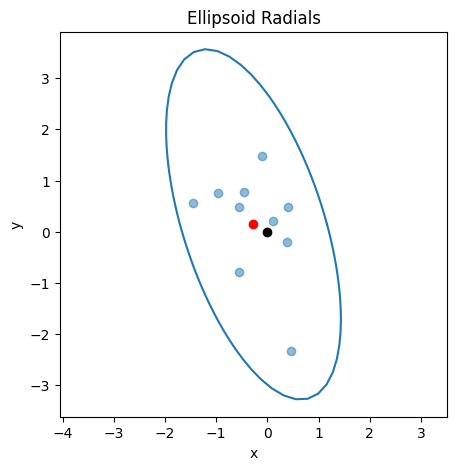

In [195]:
plt.figure(figsize=(5, 5))
plt.scatter(archetypes[:, 0], archetypes[:, 1], alpha=0.5, label="Archetypes")
plt.plot(ellipsoid[:, 0], ellipsoid[:, 1], label="Centered Gaussian Ellipsoid Radial")
plt.scatter(center[0], center[1], color='red', label="mu")
plt.scatter(0, 0, color='black', label="origin")
plt.title("Ellipsoid Radials")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.show()